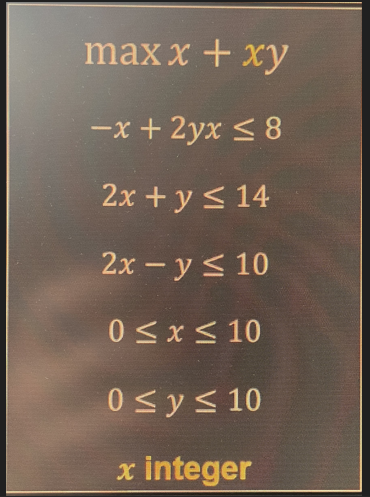

# GA

|||_______________________________________________ 6.0% GA is running...

c:\Users\f8210\miniconda3\Lib\site-packages\geneticalgorithm\geneticalgorithm.py:353: RuntimeWarning: invalid value encountered in subtract
  normobj=maxnorm-normobj+1


 The best solution found:                                                                           
 [5.         1.28382376]

 Objective function:
 -11.419118789200168


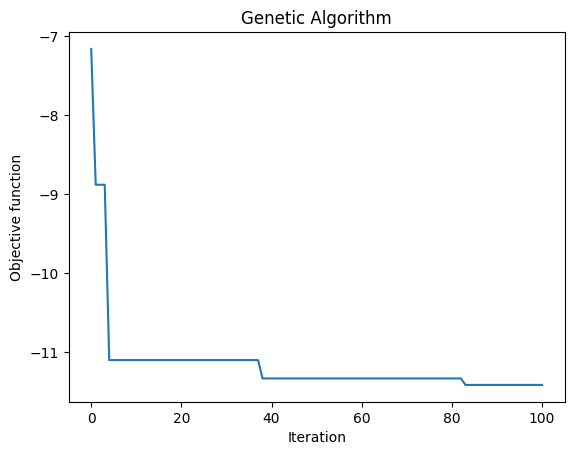

In [1]:
import numpy as np
from geneticalgorithm import geneticalgorithm as ga

def f(x):
    pen = 0
    if not -x[0]+2*x[1]*x[0]<=8: pen = np.inf
    if not 2*x[0]+x[1]<=14: pen = np.inf
    if not 2*x[0]-x[1]<=10: pen = np.inf
    return -(x[0]+x[1]*x[0]) + pen

varbounds = np.array([[0,10],[0,10]])
vartype = np.array([['int'],['real']])

algorithm_param = {'max_num_iteration': 100,\
                   'population_size':100,\
                   'mutation_probability':0.1,\
                   'elit_ratio': 0.01,\
                   'crossover_probability': 0.5,\
                   'parents_portion': 0.3,\
                   'crossover_type':'uniform',\
                   'max_iteration_without_improv':None}

model = ga(function=f,
           dimension=2,
           variable_type_mixed=vartype,
           variable_boundaries=varbounds,
           algorithm_parameters=algorithm_param)

model.run()

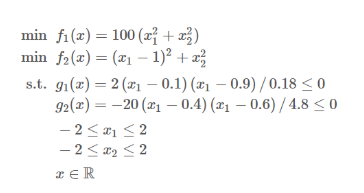

In [2]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.termination import get_termination
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
 
#definition of the problem
class MyProblem(ElementwiseProblem):
     
    def __init__(self):
        super().__init__(n_var=2,
                         n_obj=2,
                         n_constr=2,
                         xl=np.array([-2,-2]),
                         xu=np.array([2,2]))
 
    def _evaluate(self, x, out, *args, **kwargs):
        f1 = 100 * (x[0]**2 + x[1]**2)
        f2 = (x[0]-1)**2 + x[1]**2
 
        g1 = 2*(x[0]-0.1) * (x[0]-0.9) / 0.18
        g2 = - 20*(x[0]-0.4) * (x[0]-0.6) / 4.8
 
        out["F"] = [f1, f2]
        out["G"] = [g1, g2]
 
problem = MyProblem()
 
#parameters
algorithm = NSGA2(
    pop_size=40,
    n_offsprings=10,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)
 
#termination criteria
termination = get_termination("n_gen", 40)
 
#solve problem
res = minimize(problem,
               algorithm,
               termination,
               seed=1,
               save_history=True,
               verbose=True)
 
#get solutions
X = res.X
F = res.F

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       40 |      1 |  0.000000E+00 |  2.363992E+01 |             - |             -
     2 |       50 |      1 |  0.000000E+00 |  1.239636E+01 |  0.000000E+00 |             f
     3 |       60 |      2 |  0.000000E+00 |  5.4620972973 |  1.0000000000 |         ideal
     4 |       70 |      2 |  0.000000E+00 |  2.3938570636 |  0.000000E+00 |             f
     5 |       80 |      2 |  0.000000E+00 |  1.1200787779 |  0.000000E+00 |             f
     6 |       90 |      3 |  0.000000E+00 |  0.1858089725 |  0.1785481247 |             f
     7 |      100 |      4 |  0.000000E+00 |  0.0096392745 |  0.0639961700 |         ideal
     8 |      110 |      5 |  0.000000E+00 |  0.0016302512 |  0.0912676400 |         ideal
     9 |      120 |      6 |  0.000000E+00 |  0.000000E+00 |  0.1217555949 |         ideal
    10 |      130 |      6 |  0.000000E+00 |  0.000000E+00 |  0.0038809178 |             f

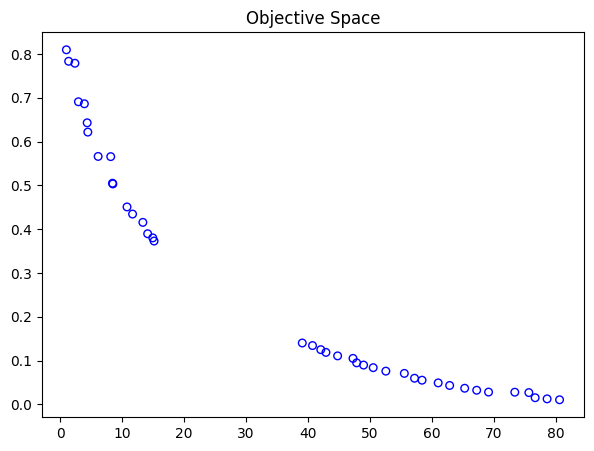

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
plt.scatter(F[:, 0], F[:, 1], s=30, facecolors='none', edgecolors='blue')
plt.title("Objective Space")
plt.show()

# PSO

In [4]:
import numpy as np
from pyswarm import pso

def model_obj(x):
    pen = 0
    # x 必須是整數
    x[0] = np.round(x[0],0)
    if not -x[0]+2*x[1]*x[0]<=8: pen = np.inf
    if not 2*x[0]+x[1]<=14: pen = np.inf
    if not 2*x[0]-x[1]<=10: pen = np.inf
    return -(x[0]+x[1]*x[0]) + pen

def cons(x):
    # 也可以把限制式寫在這裡，只是該範例寫在目標式內
    return []

lb = [0,0]
ub = [10,10]
x0 = [0,0]

xopt, fopt = pso(model_obj,lb,ub,x0,cons)

print('x =', xopt[0])
print('y =', xopt[1])

Stopping search: Swarm best objective change less than 1e-08
x = 5.0
y = 1.299999996869796
